# COM304: Algorithms
##### notebook code (C) 2021-2024 Timothy James Becker
## Chapter 3: Growth of Functions
## 3.1 <u>Asymptotic Notation<u>

An asymptote is a limit-like mathematical object (from algebra-I) that helps us to understand comlexity behavior and relationships. 

Take $y=x^2$ for example:  were does the arrow on that curve end up though? 
We will make use of our [numpy](https://numpy.org/devdocs/user/quickstart.html) and [matplotlib](https://matplotlib.org/stable/tutorials/introductory/usage.html#sphx-glr-tutorials-introductory-usage-py) libraries from here on out. If you are carefully looking at my plotting code then you may see some magical strings passed to the titles.  This is fact a language called [LaTex](https://en.wikibooks.org/wiki/LaTeX/Mathematics) and it is how I write all the math in these notebooks.

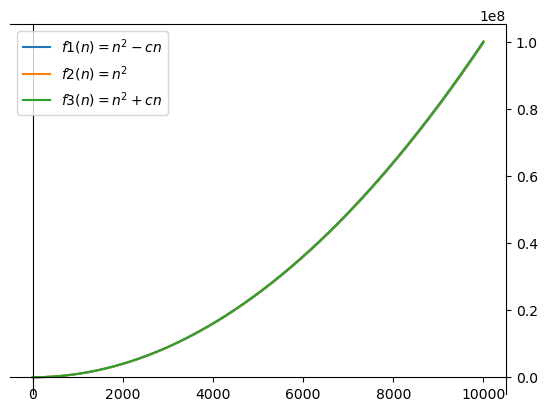

In [1]:
#set up the plotting grid--------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure();ax = fig.add_subplot(1, 1, 1)
ax.spines['bottom'].set_position('zero');ax.spines['left'].set_position('zero')
ax.xaxis.set_ticks_position('bottom');ax.yaxis.set_ticks_position('right')

#setting up the function/coefficients-------------------------------------------------
c = 20                                          #c is a constant not related to n
n = np.linspace(1,10000,10000)                      #this one will give us a linear n-axis across n integers
f1 = n**2-c*n                                   #lets do a lower bound
plt.plot(n,f1,label='$f1(n)=n^2-cn$')
f2 = n**2                                       #this is our middle function that is being sandwiched
plt.plot(n,f2,label='$f2(n)=n^2$')
f3 = n**2+c*n                                   #this one is a little bigger than the others...
plt.plot(n,f3,label='$f3(n)=n^2+cn$')
plt.legend();plt.show()

We define the time complexity of an algorithm in terms of functions whose domains are in $\mathbb{N}={0,1,2, ...}$

which in turn makes T(n) defined for integer ranges only (while it is abused for use in $\mathbb{R}$ in the text when needed.

#### <u>Big Oh, Big Omega, Big Theta</u>

$f(n) = O(g(n)) \iff f(n) \leq cg(n) \;\;\forall n>n_0: n_0,c$ are constants

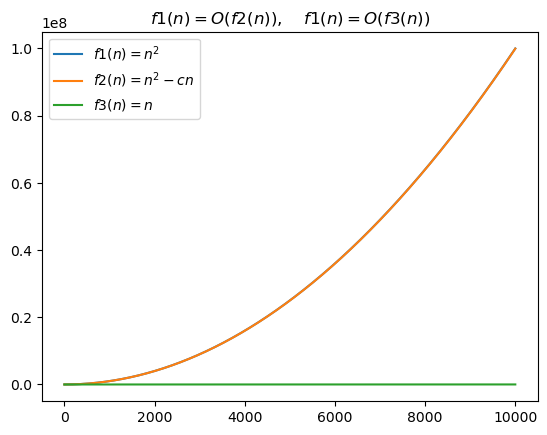

In [2]:
c = 5
n = np.linspace(1,10000,10000)                      
f1 = n**2                                   
plt.plot(n,f1,label='$f1(n)=n^2$')
f2 = n**2-c*n                                  
plt.plot(n,f2,label='$f2(n)=n^2-cn$')
f3 = n                                      
plt.plot(n,f3,label='$f3(n)=n$')
plt.title('$f1(n) = O(f2(n)),\\;\\;\\;\\;f1(n) = O(f3(n))$');
plt.legend();plt.show()

$f(n) = \Omega(g(n)) \iff f(n) \geq cg(n) \;\; \forall n>n_0: n_0,c$ are constants

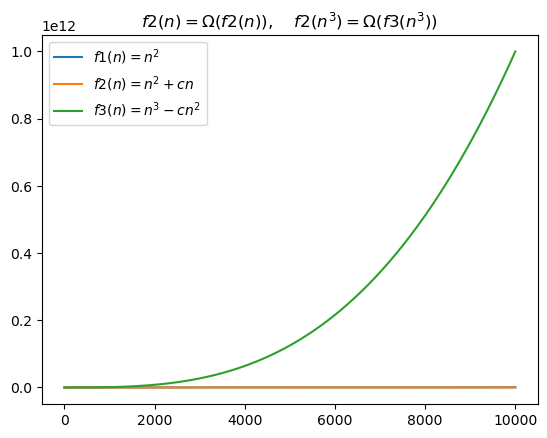

In [5]:
c = 5
n = np.linspace(1,10000,10000)                      
f1 = c*n**2                                   
plt.plot(n,f1,label='$f1(n)=n^2$')
f2 = n**2+c*n                                  
plt.plot(n,f2,label='$f2(n)=n^2+cn$')
f3 = n**3-c*n**2                                      
plt.plot(n,f3,label='$f3(n)=n^3-cn^2$')
plt.title('$f2(n) = \\Omega(f2(n)),\\;\\;\\;\\;f2(n^3) = \\Omega(f3(n^3))$');
plt.legend();plt.show()

<u>Theorem 3.2</u>

$f(n) = \Theta(g(n)) \iff f(n)=O(g(n)) \wedge f(n)=\Omega(g(n))$

NOTE: in the above plotting graph $f1(n) = \Theta(f2(n))$

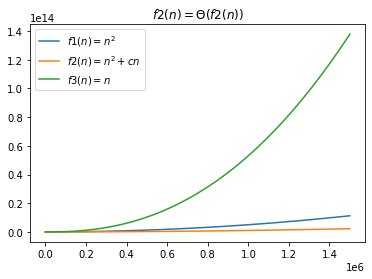

In [15]:
c = 5
n = np.linspace(1,1500000,1500000)                      
f1 = c*n**2                                   
plt.plot(n,f1,label='$f1(n)=n^2$')
f2 = n**2+c*n                                  
plt.plot(n,f2,label='$f2(n)=n^2+cn$')
f3 = n**2.3-2*c*n**2                                      
plt.plot(n,f3,label='$f3(n)=n$')
plt.title('$f2(n) = \Theta(f2(n))$');
plt.legend();plt.show()

How does this notation apply to equations and inequalities?

$n = O(n^2)$   ?

$2n^2+3n+1=2n^2+\Theta(n)$  ?



$\displaystyle \sum_{i=1}^{n}O(i)$  ?

#### <u>little oh, little omega (there is no little theta)</u>

$2n^2 = O(n^2)$ we call an asmyptotically tight bound

$2n = O(n^2)$ is a bound, but not asymptotically tight

this is where we can use little oh to make it more clear for little-oh:


$o(g(n)) = \left\{ f(n): f(n) < cg(n) \forall n \geq n_0 \wedge c>0 \right\}$

and similiarly we have little omega:

$\omega(g(n)) = \left\{ f(n): f(n) > cg(n) \forall n \geq n_0 \wedge c>0 \right\}$

### <u>Comparing Functions</u>

#### Transitivity

$f(n) = \Theta(g(n)) \wedge g(n) = \Theta(h(n)) \implies f(n) = \Theta(h(n))$

$\vdots \;\;\;\;$  also works for $\Omega, \omega, O, o$

#### Reflexivity

$f(n) = \Theta(f(n))$

$\vdots \;\;\;\;$ also works for $\Omega, O$

#### Symmetry

$f(n) = \Theta(g(n)) \iff g(n) = \Theta(f(n))$

#### Transpose Symmetry

$f(n) = O(g(n)) \iff g(n) = \Omega(f(n))$

$f(n) = o(g(n)) \iff g(n) = \omega(f(n))$

#### Trichotomy (related to the above Symmetry and Transpose Symmetry but now with real numbers)

$\forall a,b \in \mathbb{R}$ exactly one (and only one!) of the three hold:

$a<b \;\;\;\;\;\; a=b \;\;\;\;\;\; a>b$

#### <u>Practice</u> (3e) 3.1-1 (hint: $max(f(n),g(n)) = f(n)+g(n))$, 3.1-2, 3.1-7 (hint: see Appendix B.1 for help) <br> (4e) 3.2-1, 3.2-2, 3.2-7